# CH4 NetCDF Analysis

This notebook explores methane (CH4) emissions from a NetCDF dataset. The analysis includes spatial plots of methane emissions and time-series plots of average and total global methane emissions.

In [11]:
#Import packages
import xarray as xr
print("Successfully imported xarray")

import matplotlib.pyplot as plt
print("Successfully imported matplotlib.pyplot")

import numpy as np
print("Successfully imported numpy")

Successfully imported xarray
Successfully imported matplotlib.pyplot
Successfully imported numpy


In [12]:
#Open netCDF File
ds = xr.open_dataset("CRU_CH4_mch4e.nc")
ds
print("Successfully opened the NetCDF file")

Successfully opened the NetCDF file


In [13]:
#Inspecting the data

#Listing the variables in the dataset
list(ds.data_vars)
print(ds.data_vars)

#Slecting variables
ch4 = ds["mch4e"]
print(ch4)

#Checking Dimensions and Units
print(ch4.dims)
print(ch4.units)

Data variables:
    mch4e    (time, latitude, longitude) float32 4GB ...
<xarray.DataArray 'mch4e' (time: 3900, latitude: 360, longitude: 720)> Size: 4GB
[1010880000 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 31kB 1700-01-01 1700-02-01 ... 2024-12-01
  * longitude  (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * latitude   (latitude) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
Attributes:
    units:      kg CH4 m-2 months -1
    long_name:  placeholder
('time', 'latitude', 'longitude')
kg CH4 m-2 months -1


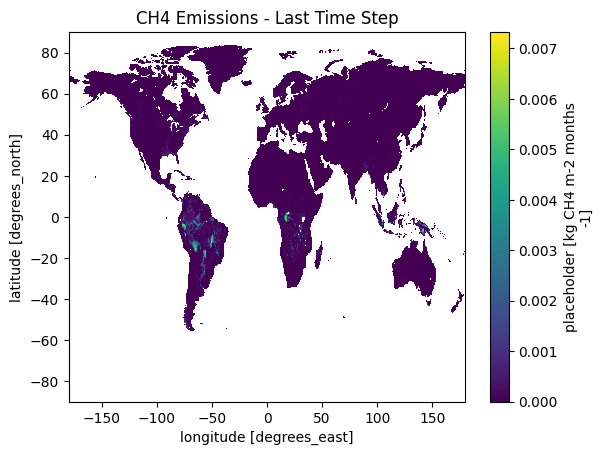

In [14]:
# Plot A: Last Time Step
ch4.isel(time=-1).plot()

plt.title("CH4 Emissions - Last Time Step")
plt.show()

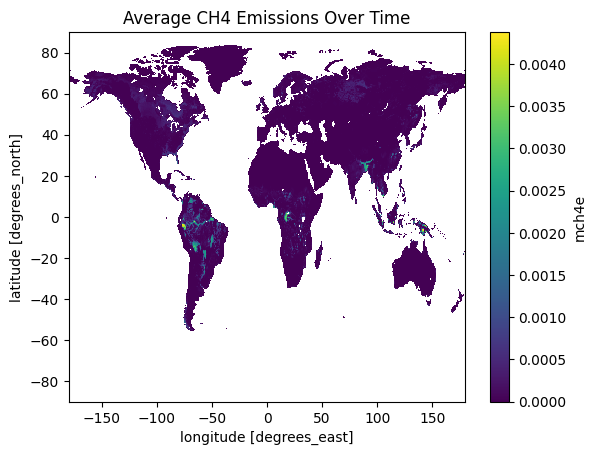

In [15]:
#Plot B: Global Average CH4 Emissions Over Time Map
ch4_mean = ch4.mean(dim="time")

ch4_mean.plot()

plt.title("Average CH4 Emissions Over Time")
plt.show()

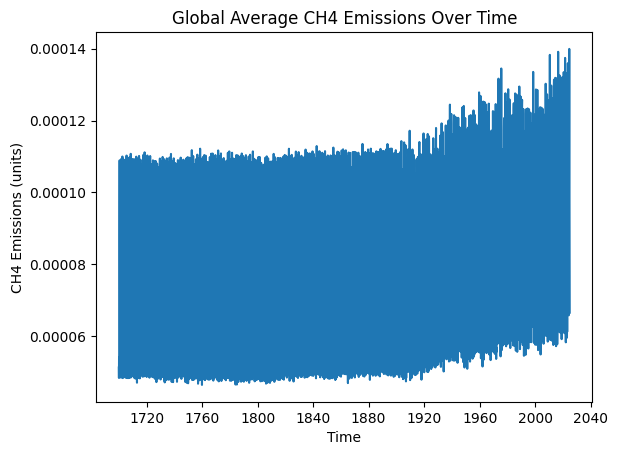

In [16]:
#Plot D: Global Average CH4 Emissions Line Plot
global_ch4 = ch4.mean(dim=["latitude", "longitude"])

global_ch4.plot()

plt.title("Global Average CH4 Emissions Over Time")
plt.xlabel("Time")
plt.ylabel("CH4 Emissions (units)")
plt.show()

kg CH4 m-2 months -1


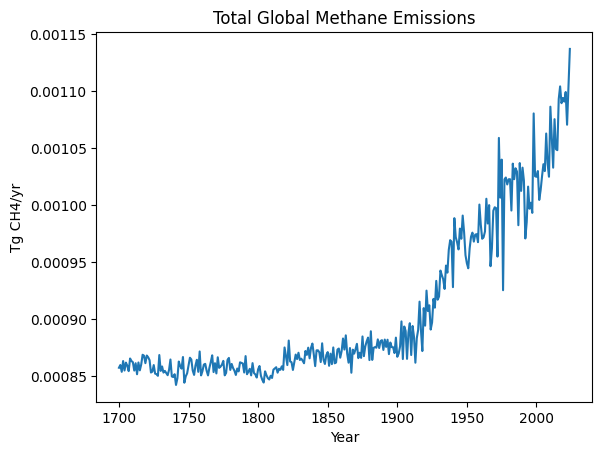

<Figure size 640x480 with 0 Axes>

In [17]:
#Tg CH4 per year
print(ch4.attrs['units'])

annual_ch4 = global_ch4.groupby("time.year").sum()

annual_ch4.plot()

plt.title("Total Global Methane Emissions")
plt.ylabel("Tg CH4/yr")
plt.xlabel("Year")
plt.show()

plt.savefig("global_ch4_tg_per_year.png", dpi=300, bbox_inches="tight")
plt.show()

#Troubleshooting Notes

In [18]:
#Locating data set file
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles Python can see:")
for file in os.listdir():
    print(file)

from pathlib import Path

path = Path("CRU_CH4_mch4e.nc")

print("Resolved path:")
print(path.resolve())

print("\nExists?")
print(path.exists())

Current working directory:
/Users/shaniabrace/Desktop/Spark/Projects/Python:netCDF/Python-netCDF

Files Python can see:
CH4_analysis.ipynb
.DS_Store
(1).venv
README.md
CRU_CH4_mch4e.nc
.gitignore
.venv
netcdf_analysis.py
global_ch4_tg_per_year.png
.git
gitignore
Resolved path:
/Users/shaniabrace/Desktop/Spark/Projects/Python:netCDF/Python-netCDF/CRU_CH4_mch4e.nc

Exists?
True


In [19]:
#After moving the notebook from .venv into the main folder 'Oython-netCDF
import os
print(os.getcwd())
print(os.listdir())

/Users/shaniabrace/Desktop/Spark/Projects/Python:netCDF/Python-netCDF
['CH4_analysis.ipynb', '.DS_Store', '(1).venv', 'README.md', 'CRU_CH4_mch4e.nc', '.gitignore', '.venv', 'netcdf_analysis.py', 'global_ch4_tg_per_year.png', '.git', 'gitignore']


In [20]:
#Checking if in the correct kernel
import sys
print(sys.executable)

/Users/shaniabrace/Desktop/Spark/Projects/Python:netCDF/Python-netCDF/(1).venv/bin/python
